## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline

In [21]:
df=pd.read_csv('Algerian_forest_fires_dataset.csv',header=1 )

In [22]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


<h4> Basic Information of data </h4>

In [ ]:
df.isnull().sum()
##data set has two different category population

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [62]:
df.shape

(246, 15)

<h4> NULL Treatment </h4>

In [28]:
# df[[df.isnull()]]
df[df.isna().any(axis=1)]
df.loc[:122,"Region"] = 1 ##It is for bijaji
df.loc[122:,"Region"] = 0 ##It is for Sidi-Be
df.head()
df[df.isna().any(axis=1)]
df.tail()
# df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,0.0
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,0.0
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,0.0
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,0.0
245,30,09,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,0.0


In [68]:
# DROPPINGG NA
df1 = df[~df.isna().any(axis=1)]
df1.loc[121:]
##dropping other row saving column as row for other dataset category
df1 = df1.drop(123, axis = 0).reset_index(drop=True)
df1.shape

(243, 15)

In [40]:
df1.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [39]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122 entries, 121 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          122 non-null    object 
 1   month        122 non-null    object 
 2   year         122 non-null    object 
 3   Temperature  122 non-null    object 
 4    RH          122 non-null    object 
 5    Ws          122 non-null    object 
 6   Rain         122 non-null    object 
 7   FFMC         122 non-null    object 
 8   DMC          122 non-null    object 
 9   DC           122 non-null    object 
 10  ISI          122 non-null    object 
 11  BUI          122 non-null    object 
 12  FWI          122 non-null    object 
 13  Classes      122 non-null    object 
 14  Region       122 non-null    float64
dtypes: float64(1), object(14)
memory usage: 15.2+ KB


In [41]:
df1.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
121,30,09,2012,25,78,14,1.4,45,1.9,7.5,0.2,2.4,0.1,not fire,1.0
124,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,0.0
125,02,06,2012,30,73,13,4,55.7,2.7,7.8,0.6,2.9,0.2,not fire,0.0
126,03,06,2012,29,80,14,2,48.7,2.2,7.6,0.3,2.6,0.1,not fire,0.0
127,04,06,2012,30,64,14,0,79.4,5.2,15.4,2.2,5.6,1,not fire,0.0


<h4> Data Formatting Adjustment </h4>

In [69]:
# df1[['day',	'month',	'year',	'Temperature',	'RH',	'Ws']]
df1.columns ## spaces in the column name giving error when referring columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [70]:
df1.columns = df1.columns.str.strip()

In [71]:
df1[['day',	'month',	'year',	'Temperature',	'RH',	'Ws']] = \
    df1[['day',	'month',	'year',	'Temperature',	'RH',	'Ws']].astype(int)

In [72]:
df1['Region'] = df1['Region'].astype(int)

In [73]:
df1.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,1
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,1
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,1
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,1
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,1


In [74]:
df1[['Rain','FFMC',	'DMC',	'DC',	'ISI',	'BUI',	'FWI'	]] = \
    df1[['Rain','FFMC',	'DMC',	'DC',	'ISI',	'BUI',	'FWI'	]].astype(float)

In [75]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [76]:
df1['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [79]:
df1['Classes'] = np.where(df1['Classes'].str.strip() == 'not fire',1,0)
# np.where(df1['Classes'].str)

In [80]:
df1['Classes'].value_counts()

Classes
0    137
1    106
Name: count, dtype: int64

In [81]:
df1.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,1
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,1
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,1
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,1
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,1


<h3> EDA </h3>

In [84]:
imp_col = df1.columns.tolist()
imp_col.pop(0)
imp_col.pop(0)
imp_col.pop(0)
imp_col

['Temperature',
 'RH',
 'Ws',
 'Rain',
 'FFMC',
 'DMC',
 'DC',
 'ISI',
 'BUI',
 'FWI',
 'Classes',
 'Region']

In [90]:
len(imp_col)-2

10

<Axes: >

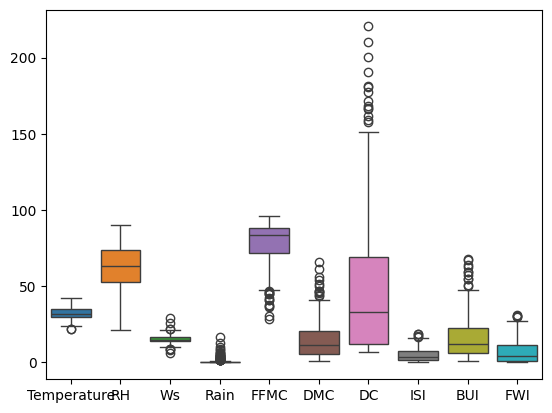

In [ ]:
##Data Distribution
sns.boxplot(df1[imp_col].drop(columns= ['Classes','Region']))
##Rain. Ws, FFMC, DMC, DC, ISI, BUI, FWI => It has Outlier

<Figure size 640x480 with 0 Axes>

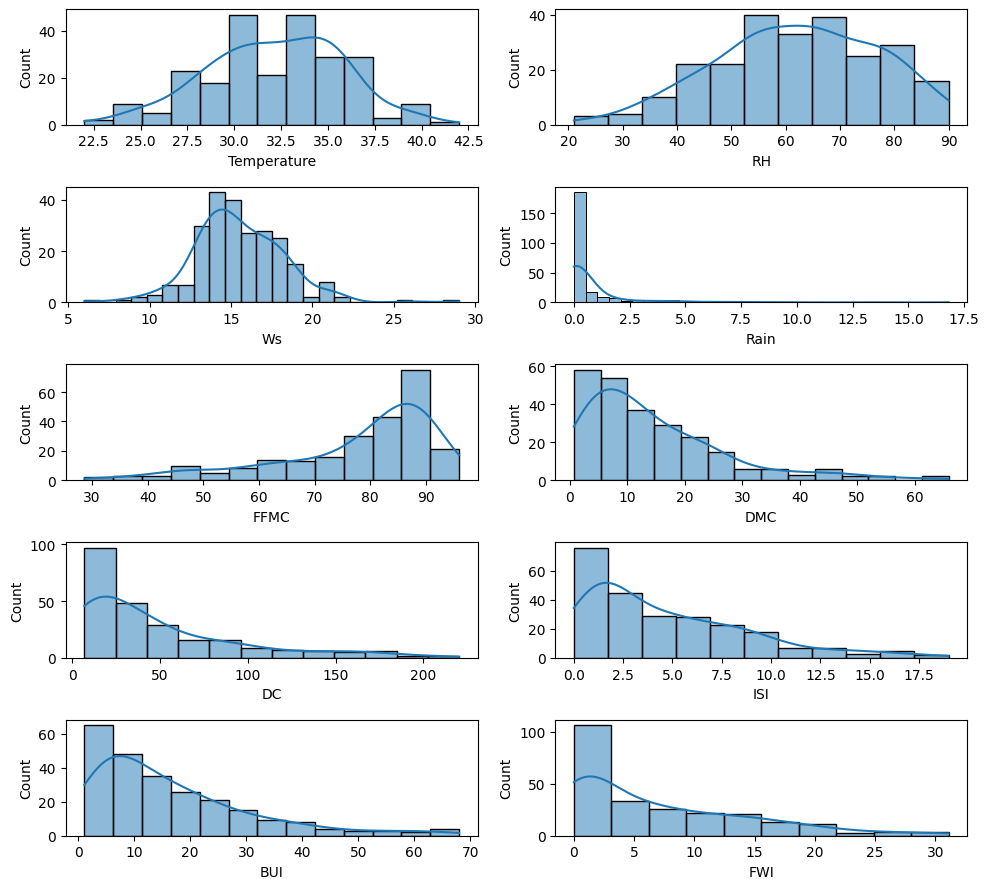

In [ ]:
##Data Distribution
plt.clf()
plt.figure(figsize=(10,9))
# plt.subplots(ncols= 2, nrows=)
for i in range(1,11):
    # plt.figure(figsize=(5,6))
    plt.subplot(5,2,i)
    sns.histplot(df1[imp_col].drop(columns= ['Classes','Region']).iloc[:,i-1], kde= True)

plt.tight_layout()
plt.show()

##RH, Temperature, Ws is Normal, WS has Outlier
##Left Skewed: RH & FFMC
##Right Skewed:Rest all are Right Skewed

<h3> Conclusions: </h3>

About Outliers:
Rain, Ws, FFMC, DMC, DC, ISI, BUI, FWI => they've Outlier 

*** About Distribution: *** 

RH, Temperature, Ws is Normal

Left Skewed: RH & FFMC

Right Skewed:Rest all are Right Skewed

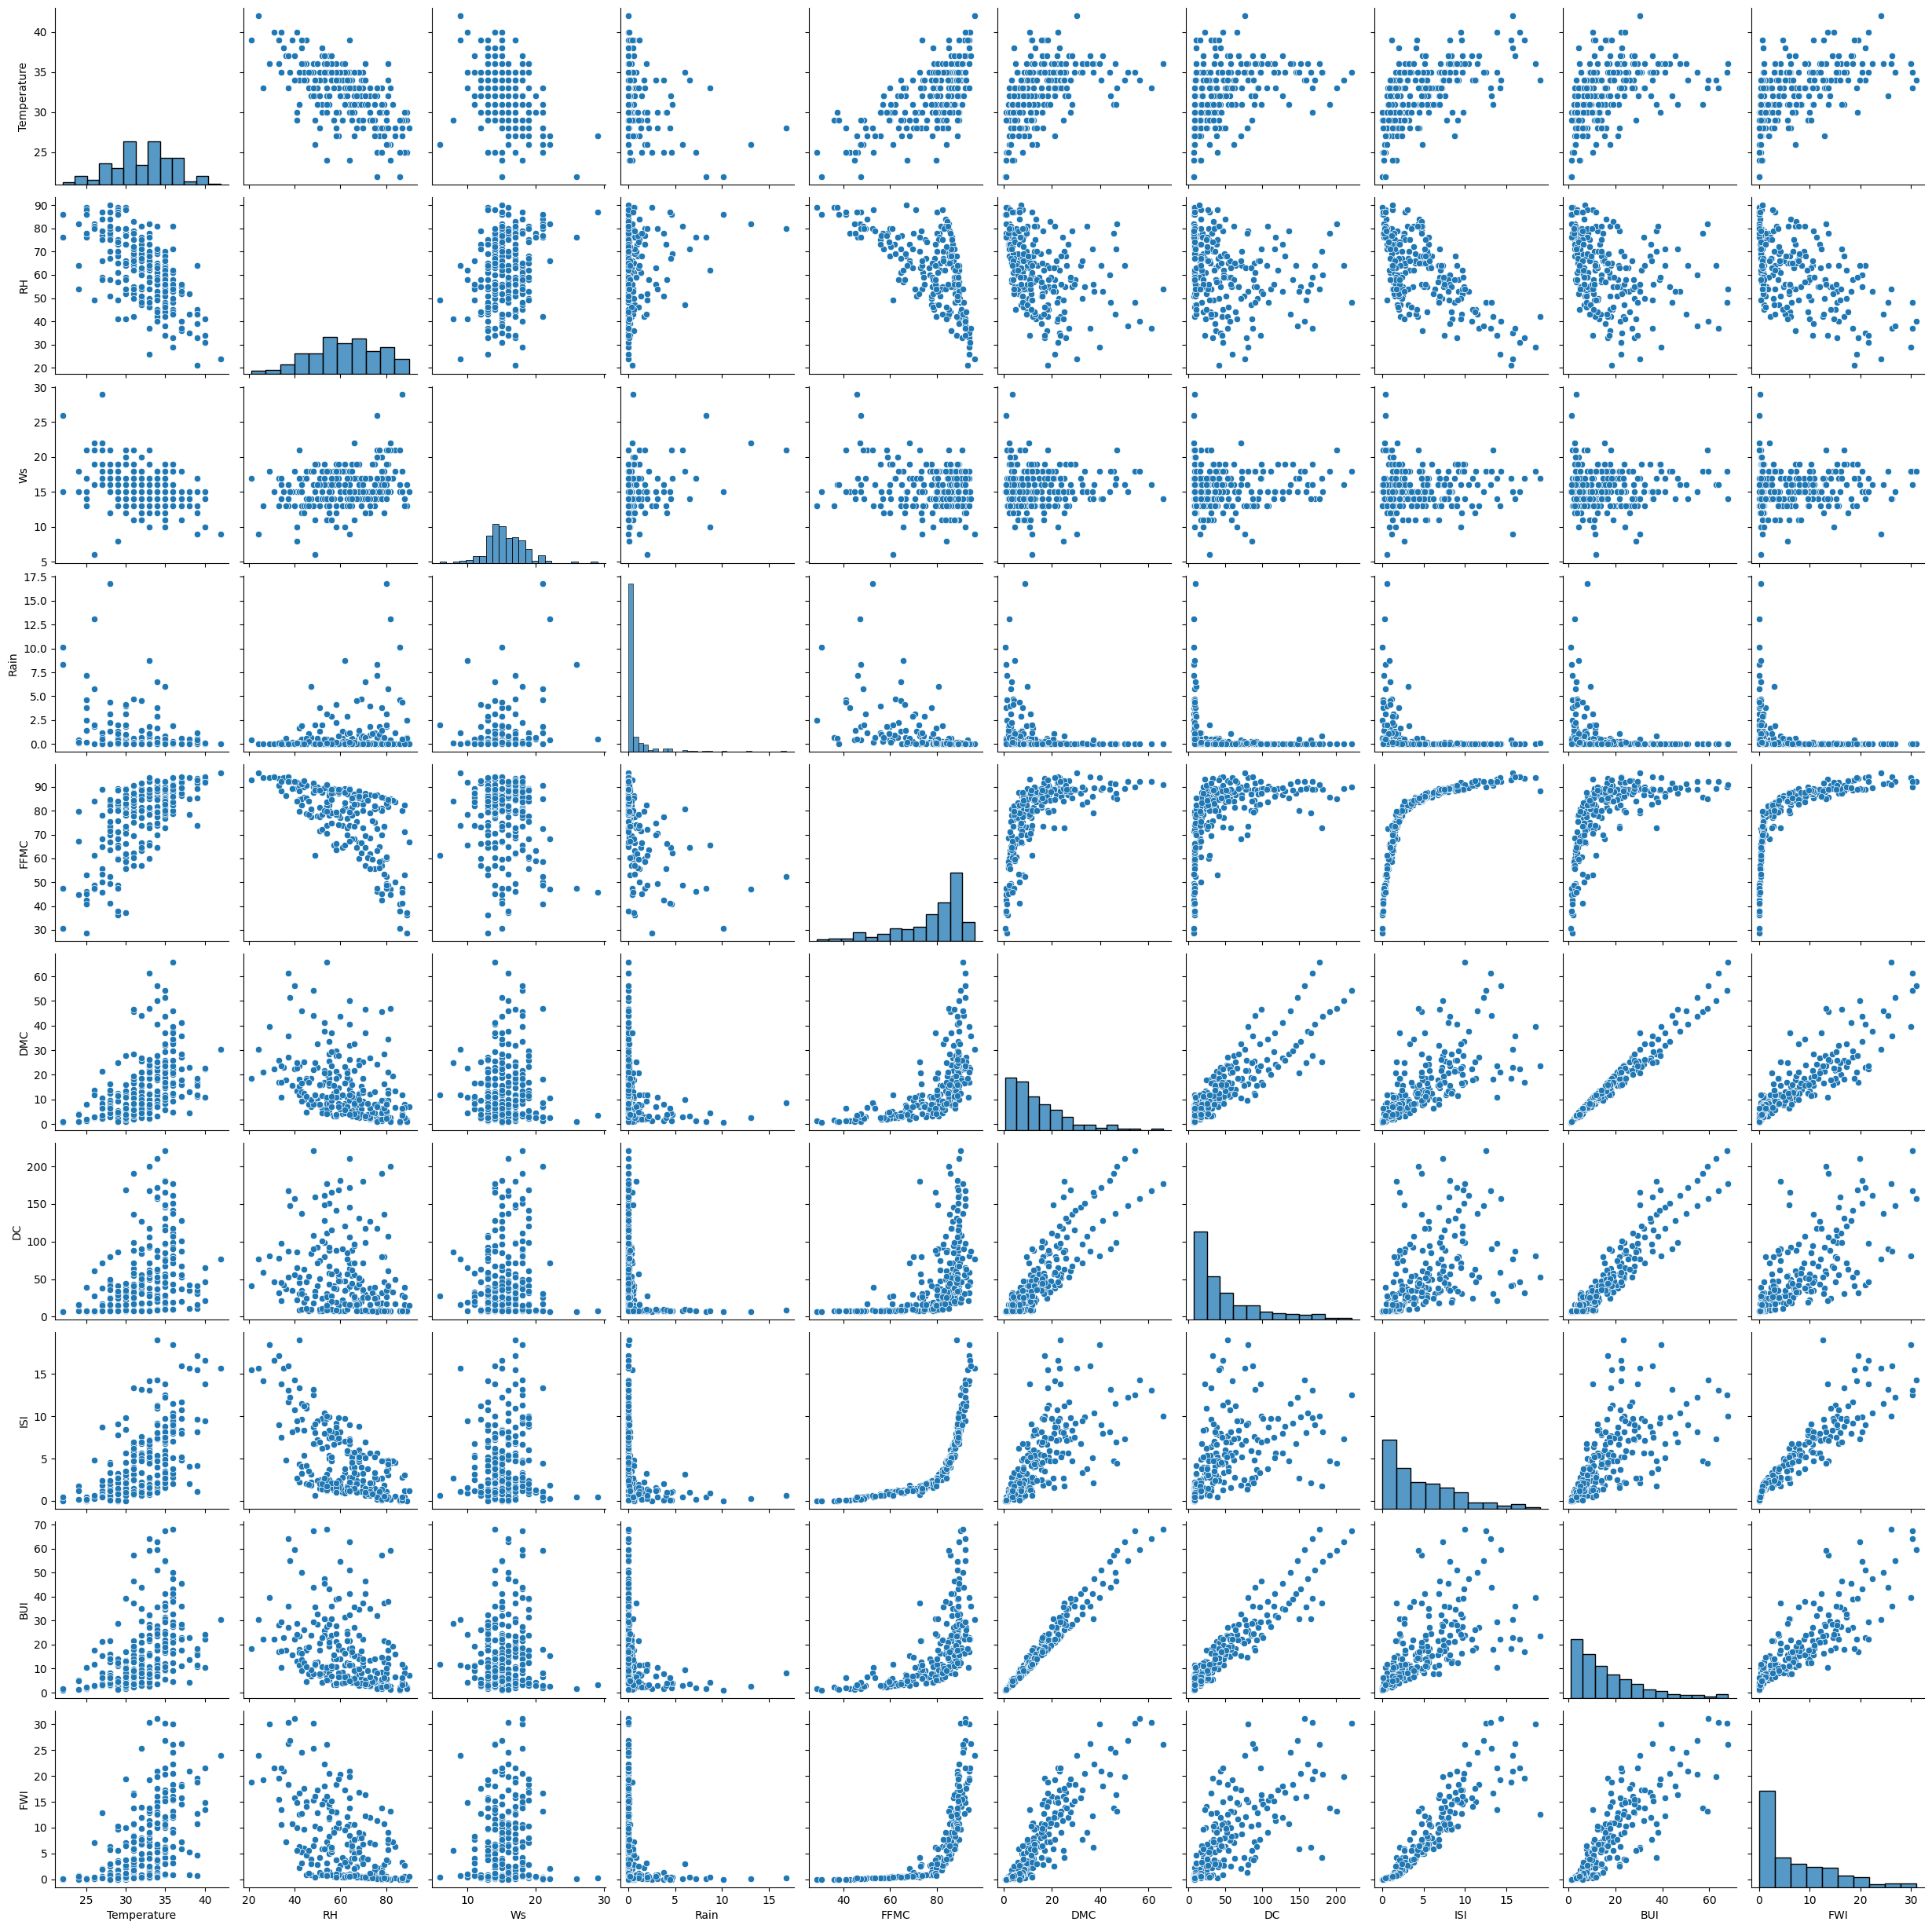

In [ ]:
sns.pairplot(df1[imp_col].drop(columns= ['Classes','Region']))
# df1[imp_col].drop(columns= ['Classes','Region'])


** Correlations **

can see correlations => some shows non-linear corr 
FFMC has : FWI, BUI, ISI, DC, DMC, RH

Linear Relations:rest of variables


<Axes: >

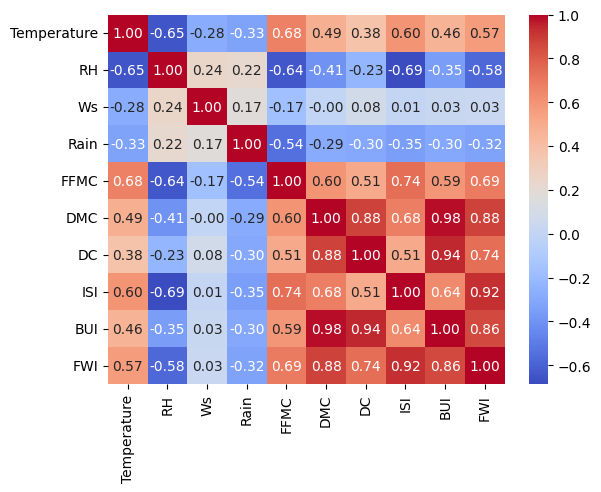

In [ ]:
sns.heatmap(data= df1[imp_col].drop(columns= ['Classes','Region']).corr(), annot= True, fmt=".2f", cmap= 'coolwarm' )

Red Colors shows +ve correlation: DMC |DC , BUI => Strong +ve 

FFMC have correlation but since not exact linear => that is why it is not too high

So, rather than using Correlation alon I should VIF as well

In [126]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [128]:
vif_data = pd.DataFrame()
vif_data['Feature'] =  df1[imp_col].drop(columns= ['Classes','Region']).columns
vif_data['VIF'] = [variance_inflation_factor( df1[imp_col].drop(columns= ['Classes','Region']).values, i) \
                   for i in range( df1[imp_col].drop(columns= ['Classes','Region']).shape[1])]

In [ ]:
##Over 10 is alarming
vif_data.sort_values(by = 'VIF', ascending= False) ## All variables too highly correlated with each other

,Feature,VIF
8,BUI,402.844539
5,DMC,182.267139
4,FFMC,105.119288
0,Temperature,97.658881
9,FWI,76.318272
7,ISI,52.266821
6,DC,51.197446
2,Ws,34.762862
1,RH,30.626211
3,Rain,1.652117


In [154]:
##Can check high correlated factors, part of it can be tackled using Ridge modelling
col1 = df1[imp_col].drop(columns= ['Classes','Region']).columns
df2 = df1[imp_col].drop(columns= ['Classes','Region'])

df_cor_x1 = []
df_cor_x2 = []
df_cor_VAL = []

# df1[imp_col].drop(columns= ['Classes','Region']).columns
rw = 0
for i in range(len(col1)):
    for j in col1[i+1:]:
        df_cor_x1.append(col1[i]) 
        df_cor_x2.append(j) 
        df_cor_VAL.append(float(np.corrcoef(df2.iloc[:,i],df2[j])[1][0]))


In [158]:
df_cor = pd.DataFrame({'x1':df_cor_x1, 'x2': df_cor_x2,'val':df_cor_VAL})
df_cor['val_Abs'] = abs(df_cor['val'])

In [ ]:
df_cor[df_cor['val_Abs'] > 0.85]

,x1,x2,val,val_Abs
35,DMC,DC,0.875925,0.875925
37,DMC,BUI,0.982248,0.982248
38,DMC,FWI,0.875864,0.875864
40,DC,BUI,0.941988,0.941988
43,ISI,FWI,0.922895,0.922895
44,BUI,FWI,0.857973,0.857973


Conclusion related to Correlation

##DMC Is highly correlated & FWI it is target variable

##DMC:  FWI, BUI, DC 

##FWI: ISI, BUI, DMC

##BUI: DMC,DC, FWI

#So, dropping DMC, BUI => highly correlated with variable other than target variable

In [165]:
## Percentage for Pie Chart
percentage=df1['Classes'].value_counts(normalize=True)*100

In [170]:
percentage

Classes
0    56.378601
1    43.621399
Name: proportion, dtype: float64

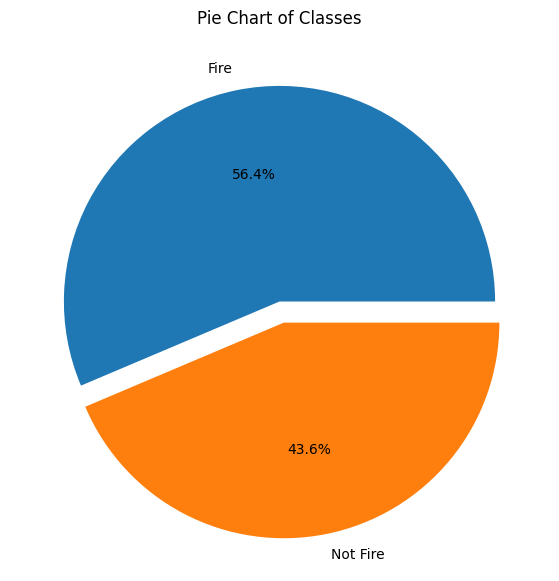

In [174]:
# plotting piechart
classlabels=["Fire","Not Fire"]
plt.figure(figsize=(12,7))
explode = [0, 0.1]
plt.pie(percentage,labels=classlabels, autopct='%1.1f%%', explode=explode)
# plt.pie(percentage,labels=classlabels,autopct='%1.1f%%',)
plt.title("Pie Chart of Classes")
plt.show()

Dataset is not Imbalanced

In [188]:
# Combine into year-month period
df1['date'] = pd.to_datetime(df1[['year','month','day']].assign(Day=1))

df1.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,date
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,1,2012-06-01
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,1,2012-06-01
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,1,2012-06-01
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,1,2012-06-01
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,1,2012-06-01


In [205]:
df_counts = df1.groupby(['date', 'Classes']).size().reset_index(name='count')
df_counts['Classes1'] = df_counts['Classes'].map({1: "not fire", 0: "fire"})
df_counts.head()

,date,Classes,count,Classes1
0,2012-06-01,0,25,fire
1,2012-06-01,1,35,not fire
2,2012-07-01,0,38,fire
3,2012-07-01,1,23,not fire
4,2012-08-01,0,51,fire


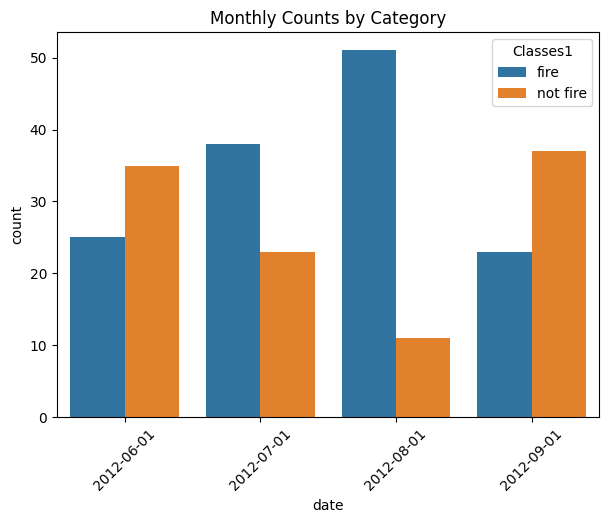

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(data=df_counts, x='date', y='count', hue='Classes1')
plt.title("Monthly Counts by Category")
plt.xticks(rotation=45)
# plt.legend(title="Fire Status", labels=['fire',"not fire"])
plt.show()


Its observed that August and July had the most number of forest fires for both regions. 

In [210]:
df1.head()
df1.to_csv('Algerian_clean_df.csv',index= False)

## Modelling

In [208]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.model_selection import train_test_split

In [211]:
df1.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,date
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,1,2012-06-01
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,1,2012-06-01
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,1,2012-06-01
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,1,2012-06-01
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,1,2012-06-01


In [366]:
col2 = col1.tolist()
col2.pop()

'FWI'

In [218]:
col2.extend(['Classes','Region'])

In [219]:
col2

['Temperature',
 'RH',
 'Ws',
 'Rain',
 'FFMC',
 'DMC',
 'DC',
 'ISI',
 'BUI',
 'Classes',
 'Region']

In [222]:
X = df1.loc[:,col2]
y = df1.loc[:,['FWI']]

## Splitting Data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [224]:
X.shape,y.shape


((243, 11), (243, 1))

<h4> Pipeline </h4>

In [228]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [225]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,1,1
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,1,1
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,1,1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,1,1
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,1,1


In [ ]:
##Temperature	RH => Normal (Using Standard Scaler)
# Left: FFMC
#Right rest: Ws, Rain, DMC,	DC, ISI, BUI
##Skewness use yeo-johnson => then Robust Scaler
## Temperature => No transformation => Using StandarScaler

In [226]:
norm = ['Temperature']
var_skew = ['RH','Ws','Rain','FFMC','DMC','DC','ISI','BUI']

In [ ]:
st = StandardScaler()
pt = PowerTransformer(method='yeo-johnson')
rb = RobustScaler()

In [229]:
##Pipeline Creation for skewed variables
##Why creating pipeline, as it has two steps
skewed_pipeline = Pipeline([
    ('power', pt),
    ('robust', rb)
])

##remainder = pass through ensures the columns if there aren't any column in trasfn pass them ass is 
preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), norm),
    ('skew', skewed_pipeline, var_skew)
], remainder='passthrough')

linear_reg_pipeline = Pipeline([
    ('transform', preprocessor),
    ('lr', LinearRegression())
])

In [230]:
linear_reg_pipeline.fit(X_train, y_train)

,steps,"[('transform', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('std', ...), ('skew', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [259]:
# pd.DataFrame({'feature_nm':linear_reg_pipeline.named_steps['transform'].get_feature_names_out().ravel().tolist(), 
#               'Linear_coeff': linear_reg_pipeline.named_steps['lr'].coef_ })
coeffs_df = pd.DataFrame({'feature_nm':linear_reg_pipeline.named_steps['transform'].get_feature_names_out().ravel().tolist()\
                          ,'Linear_coeff':linear_reg_pipeline.named_steps['lr'].coef_.ravel().tolist() })
# linear_reg_pipeline.named_steps['lr'].coef_.ravel().tolist()

<H7> Evaluation for Test Data </H7>

In [231]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,linear_reg_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,linear_reg_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,linear_reg_pipeline.predict(X_test))),2)) ## Unit issue

MEAN ABSOLUTE ERROR: 2.16
MEAN SQUARED ERROR: 8.23
ROOT MEAN SQUARED ERROR: 2.87


In [234]:
##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,linear_reg_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))

R2: 0.73
Adjusted R2: 0.65


<H7> Evaluation for Train Data </H7>

In [238]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_train,linear_reg_pipeline.predict(X_train)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_train,linear_reg_pipeline.predict(X_train)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_train,linear_reg_pipeline.predict(X_train))),2)) ## Unit issue

score_tst = metrics.r2_score(y_train,linear_reg_pipeline.predict(X_train))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 1.83
MEAN SQUARED ERROR: 6.61
ROOT MEAN SQUARED ERROR: 2.57
R2: 0.89
Adjusted R2: 0.88


<H3> Ridge Regression </H3>

In [260]:
##REDUCE THE POWER OF REDUDANT FEATURE
##NOT REDUCE TO ZERO
## GOOD FOR MULTICOLINEARITY, WHICH IS THE CASE HERE

ridge_pipeline = Pipeline([
    ('transform', preprocessor),
    ('Rig', Ridge())
])

In [261]:
ridge_pipeline.fit(X_train, y_train)

,steps,"[('transform', ...), ('Rig', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('std', ...), ('skew', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<H7> Evaluation for Train Data </H7>

In [262]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_train,ridge_pipeline.predict(X_train)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_train,ridge_pipeline.predict(X_train)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_train,ridge_pipeline.predict(X_train))),2)) ## Unit issue

score_tst = metrics.r2_score(y_train,ridge_pipeline.predict(X_train))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 2.05
MEAN SQUARED ERROR: 7.69
ROOT MEAN SQUARED ERROR: 2.77
R2: 0.87
Adjusted R2: 0.87


<H7> Evaluation for Test Data </H7>

In [263]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,ridge_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,ridge_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,ridge_pipeline.predict(X_test))),2)) ## Unit issue

score_tst1 = metrics.r2_score(y_test,ridge_pipeline.predict(X_test))
print("R2:" ,round(score_tst1,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst1)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 2.1
MEAN SQUARED ERROR: 7.13
ROOT MEAN SQUARED ERROR: 2.67
R2: 0.76
Adjusted R2: 0.75


In [265]:
coeffs_df['Ridge_coef'] = ridge_pipeline.named_steps['Rig'].coef_.ravel().tolist() 

In [266]:
coeffs_df.head()

,feature_nm,Linear_coeff,Ridge_coef
0,std__Temperature,-0.537978,-0.489388
1,skew__RH,-0.603284,-0.527161
2,skew__Ws,-0.623034,-0.105985
3,skew__Rain,0.831208,0.932197
4,skew__FFMC,-12.835481,-5.612203


In [270]:
coeffs_df['feature_nm'] = coeffs_df['feature_nm'].str.split('_').apply(lambda x: x[-1])

In [271]:
coeffs_df.head()

,feature_nm,Linear_coeff,Ridge_coef
0,Temperature,-0.537978,-0.489388
1,RH,-0.603284,-0.527161
2,Ws,-0.623034,-0.105985
3,Rain,0.831208,0.932197
4,FFMC,-12.835481,-5.612203


<H3> Lasso Regression </H3>

In [272]:
##Good for Feature Selection
lasso_pipeline = Pipeline([
    ('transform', preprocessor),
    ('laso', Lasso())
])

In [274]:
lasso_pipeline.fit(X_train,y_train)

,steps,"[('transform', ...), ('laso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('std', ...), ('skew', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<H7> Evaluation for Train Data </H7>

In [275]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_train,lasso_pipeline.predict(X_train)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_train,lasso_pipeline.predict(X_train)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_train,lasso_pipeline.predict(X_train))),2)) ## Unit issue

score_tst2 = metrics.r2_score(y_train,lasso_pipeline.predict(X_train))
print("R2:" ,round(score_tst2,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst2)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 2.72
MEAN SQUARED ERROR: 12.83
ROOT MEAN SQUARED ERROR: 3.58
R2: 0.79
Adjusted R2: 0.78


<H7> Evaluation for Test Data </H7>

In [276]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,lasso_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,lasso_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,lasso_pipeline.predict(X_test))),2)) ## Unit issue

score_tst4 = metrics.r2_score(y_test,lasso_pipeline.predict(X_test))
print("R2:" ,round(score_tst4,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst4)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 2.38
MEAN SQUARED ERROR: 7.33
ROOT MEAN SQUARED ERROR: 2.71
R2: 0.76
Adjusted R2: 0.74


In [291]:
coeffs_df['Lasso_coef'] = lasso_pipeline.named_steps['laso'].coef_.ravel().tolist() 

In [280]:
coeffs_df ##It's juts kept 2 coeffs => DMC, ISI

,feature_nm,Linear_coeff,Ridge_coef,Lasso_coef
0,Temperature,-0.537978,-0.489388,0.000000
1,RH,-0.603284,-0.527161,-0.000000
2,Ws,-0.623034,-0.105985,0.000000
3,Rain,0.831208,0.932197,-0.000000
4,FFMC,-12.835481,-5.612203,0.000000
5,DMC,16.354927,4.662656,3.881127
6,DC,7.875575,2.183458,0.000000
7,ISI,19.685984,13.189808,5.124115
8,BUI,-16.561578,-0.974120,0.000000
9,Classes,0.654305,0.657621,-0.000000


<H3> Elasticnet Regression </H3>

In [285]:
##Good for Feature Selection & Multicollinearity
Elastic_pipeline = Pipeline([
    ('transform', preprocessor),
    ('elas', ElasticNet())
])

In [286]:
Elastic_pipeline.fit(X_train,y_train)

,steps,"[('transform', ...), ('elas', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('std', ...), ('skew', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<H7> Evaluation for Train Data </H7>

In [287]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_train,Elastic_pipeline.predict(X_train)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_train,Elastic_pipeline.predict(X_train)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_train,Elastic_pipeline.predict(X_train))),2)) ## Unit issue

score_tst5 = metrics.r2_score(y_train,Elastic_pipeline.predict(X_train))
print("R2:" ,round(score_tst2,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst5)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 3.03
MEAN SQUARED ERROR: 16.37
ROOT MEAN SQUARED ERROR: 4.05
R2: 0.79
Adjusted R2: 0.71


<H7> Evaluation for Test Data </H7>

In [297]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,Elastic_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,Elastic_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,Elastic_pipeline.predict(X_test))),2)) ## Unit issue

score_tst6 = metrics.r2_score(y_test,Elastic_pipeline.predict(X_test))
print("R2:" ,round(score_tst6,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst6)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 2.63
MEAN SQUARED ERROR: 9.45
ROOT MEAN SQUARED ERROR: 3.07
R2: 0.69
Adjusted R2: 0.67


In [290]:
coeffs_df['Elastic_coef'] = Elastic_pipeline.named_steps['elas'].coef_.ravel().tolist() 

In [292]:
coeffs_df

,feature_nm,Linear_coeff,Ridge_coef,Lasso_coef,Elastic_coef
0,Temperature,-0.537978,-0.489388,0.000000,0.606105
1,RH,-0.603284,-0.527161,-0.000000,-0.769048
2,Ws,-0.623034,-0.105985,0.000000,0.101226
3,Rain,0.831208,0.932197,-0.000000,-0.379428
4,FFMC,-12.835481,-5.612203,0.000000,1.020077
5,DMC,16.354927,4.662656,3.881127,1.669010
6,DC,7.875575,2.183458,0.000000,0.746663
7,ISI,19.685984,13.189808,5.124115,1.617862
8,BUI,-16.561578,-0.974120,0.000000,1.482636
9,Classes,0.654305,0.657621,-0.000000,-0.536299


<h3> Tuning </h3>

In [293]:
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV

In [ ]:
ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],cv=5)

In [301]:
Elastic_cv_pipeline = Pipeline([
    ('transform', preprocessor),
    ('elas_cv', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], alphas=[0,1,.1,15,.5,10,5],cv=5))
])

In [302]:
Elastic_cv_pipeline.fit(X_train,y_train)

c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.119e+02, tolerance: 9.104e-01
  model = cd_fast.enet_coordin

,steps,"[('transform', ...), ('elas_cv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('std', ...), ('skew', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [303]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,Elastic_cv_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,Elastic_cv_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,Elastic_cv_pipeline.predict(X_test))),2)) ## Unit issue

score_tst7 = metrics.r2_score(y_test,Elastic_cv_pipeline.predict(X_test))
print("R2:" ,round(score_tst7,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst7)*(X_train.shape[0]-1))/(X_train.shape[0]-X_train.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 2.17
MEAN SQUARED ERROR: 8.28
ROOT MEAN SQUARED ERROR: 2.88
R2: 0.73
Adjusted R2: 0.71


<h4> Dropping the Unnecessary Columns </h4>

In [ ]:
df1_copy = df1.drop(columns=['DMC']) ##BUI has high correlation with target variable that is why instead DMC Removed

In [390]:
col3 = col2.copy()
col3.pop(-4)

'DMC'

In [391]:
X_n = df1_copy.loc[:,col3]
y_n = df1_copy.loc[:,['FWI']]

## Splitting Data
X_train, X_test, y_train, y_test = train_test_split( X_n, y_n, test_size=0.2, random_state=42)

In [373]:
norm = ['Temperature']
var_skew = ['RH','Ws','Rain','FFMC','DMC','DC','ISI']

In [374]:
##Pipeline Creation for skewed variables
##Why creating pipeline, as it has two steps
skewed_pipeline = Pipeline([
    ('power', pt),
    ('robust', rb)
])

##remainder = pass through ensures the columns if there aren't any column in trasfn pass them ass is 
preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), norm),
    ('skew', skewed_pipeline, var_skew)
], remainder='passthrough')

linear_reg_pipeline = Pipeline([
    ('transform', preprocessor),
    ('lr', LinearRegression())
])

In [375]:
linear_reg_pipeline.fit(X_train, y_train)

,steps,"[('transform', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('std', ...), ('skew', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [376]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,linear_reg_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,linear_reg_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,linear_reg_pipeline.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,linear_reg_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))

MEAN ABSOLUTE ERROR: 1.99
MEAN SQUARED ERROR: 7.01
ROOT MEAN SQUARED ERROR: 2.65
R2: 0.77
Adjusted R2: 0.72


In [395]:
linear_reg_pipeline = Pipeline([
    ('transform', RobustScaler()),
    ('lr', LinearRegression())
])

In [396]:
linear_reg_pipeline.fit(X_train, y_train)

,steps,"[('transform', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,fit_intercept,True
,copy_X,True


In [397]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,linear_reg_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,linear_reg_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,linear_reg_pipeline.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,linear_reg_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))


MEAN ABSOLUTE ERROR: 0.42
MEAN SQUARED ERROR: 0.35
ROOT MEAN SQUARED ERROR: 0.59
R2: 0.99
Adjusted R2: 0.99


<h5> This shows skew transformation & their respective adjustment adversely impacted power of Prediction </h5>

In [331]:
ridge_n_pipeline = Pipeline([
    ('transform', RobustScaler()),
    ('lr', Ridge())
])

In [401]:
ridge_n_pipeline.fit(X_train,y_train)

,steps,"[('transform', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,alpha,1.0
,fit_intercept,True


In [402]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,ridge_n_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,ridge_n_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,ridge_n_pipeline.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,ridge_n_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))



MEAN ABSOLUTE ERROR: 0.46
MEAN SQUARED ERROR: 0.41
ROOT MEAN SQUARED ERROR: 0.64
R2: 0.99
Adjusted R2: 0.98


In [403]:
lasso_n_pipeline = Pipeline([
    ('transform', RobustScaler()),
    ('lr', Lasso())
])

In [404]:
lasso_n_pipeline.fit(X_train,y_train)

,steps,"[('transform', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,alpha,1.0
,fit_intercept,True


In [405]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,lasso_n_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,lasso_n_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,lasso_n_pipeline.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,lasso_n_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))
##Multicollinearity exists that was shown by VIF so best to use Ridge

MEAN ABSOLUTE ERROR: 1.12
MEAN SQUARED ERROR: 1.93
ROOT MEAN SQUARED ERROR: 1.39
R2: 0.94
Adjusted R2: 0.92


In [406]:
elast_n_pipeline = Pipeline([
    ('transform', RobustScaler()),
    ('lr', ElasticNet())
])

In [407]:
elast_n_pipeline.fit(X_train, y_train)

,steps,"[('transform', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,alpha,1.0
,l1_ratio,0.5


In [408]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,elast_n_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,elast_n_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,elast_n_pipeline.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,elast_n_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))
##Multicollinearity exists that was shown by VIF so best to use Ridge

MEAN ABSOLUTE ERROR: 2.07
MEAN SQUARED ERROR: 6.42
ROOT MEAN SQUARED ERROR: 2.53
R2: 0.79
Adjusted R2: 0.75


Tuning

In [344]:
Elastic_cv_pipeline = Pipeline([
    ('transform', RobustScaler()),
    ('elas_cv', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], alphas=[0,1,.1,15,.5,10,5],cv=5))
])

In [411]:
Elastic_cv_pipeline.fit(X_train, y_train)

c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\rachi\OneDrive\Desktop\Python Learning

,steps,"[('transform', ...), ('elas_cv', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,l1_ratio,"[0.1, 0.5, ...]"
,eps,0.001


In [412]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,Elastic_cv_pipeline.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,Elastic_cv_pipeline.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,Elastic_cv_pipeline.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,Elastic_cv_pipeline.predict(X_test))
print("R2:" ,round(score_tst,2))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),2))
##Multicollinearity exists that was shown by VIF so best to use Ridge

MEAN ABSOLUTE ERROR: 0.42
MEAN SQUARED ERROR: 0.35
ROOT MEAN SQUARED ERROR: 0.59
R2: 0.99
Adjusted R2: 0.99
